In [ ]:
from palmerpenguins import load_penguins
import pandas as pd

df = load_penguins()

viz_df = df.dropna(subset=[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex"
])

print(viz_df.shape)
print(viz_df.isna().sum())

ModuleNotFoundError: No module named 'palmerpenguins'

In [ ]:
print(viz_df["species"].unique())
print(viz_df["island"].unique())
print(viz_df["sex"].unique())
species_colors = {
    "Adelie": "#1f77b4", # blue 
    "Gentoo": "#2ca02c", # green 
    "Chinstrap": "#ff7f0e" # orange 
}

NameError: name 'viz_df' is not defined

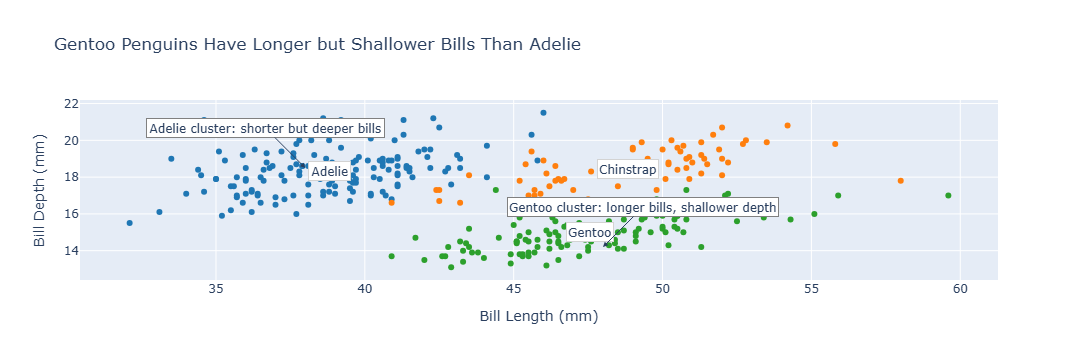

In [ ]:
import plotly.express as px

fig_scatter = px.scatter(
    viz_df,
    x="bill_length_mm",
    y="bill_depth_mm",
    color="species",
    color_discrete_map=species_colors,
    hover_data=["island", "flipper_length_mm", "body_mass_g"],
    title="Gentoo Penguins Have Longer but Shallower Bills Than Adelie"
)

fig_scatter.update_layout(
    xaxis_title="Bill Length (mm)",
    yaxis_title="Bill Depth (mm)",
    showlegend=False
)

# Add direct labels at cluster centers
cluster_centers = (
    viz_df.groupby("species")[["bill_length_mm", "bill_depth_mm"]]
    .mean()
    .reset_index()
)

for _, row in cluster_centers.iterrows():
    fig_scatter.add_annotation(
        x=row["bill_length_mm"],
        y=row["bill_depth_mm"],
        text=row["species"],
        showarrow=False,
        font=dict(size=12),
        bgcolor="white",
        bordercolor="lightgray",
        borderwidth=1
    )
    
fig_scatter.add_annotation(
    x=48,
    y=14.2,
    text="Gentoo cluster:\nlonger bills, shallower depth",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40,
    bgcolor="white",
    bordercolor="gray",
    borderwidth=1
)

fig_scatter.add_annotation(
    x=38,
    y=18.5,
    text="Adelie cluster:\nshorter but deeper bills",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-40,
    bgcolor="white",
    bordercolor="gray",
    borderwidth=1
)

fig_scatter.show()

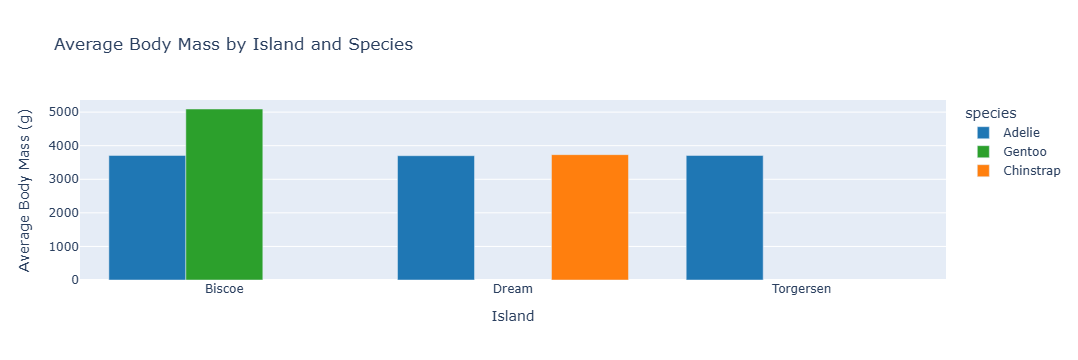

In [ ]:
island_species = (
    viz_df.groupby(["island", "species"])
    .size()
    .reset_index(name="count")
)
heatmap_df = island_species.pivot(index="species", columns="island", values="count").fillna(0)

fig = px.imshow(
    heatmap_df,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="Blues",
    title="Adelie Appear on All Three Islands, While Gentoo and Chinstrap Appear on One Each",
    labels=dict(x="Island", y="Species", color="Penguin Count")
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_traces(
    textfont_size=14
)

fig.show()

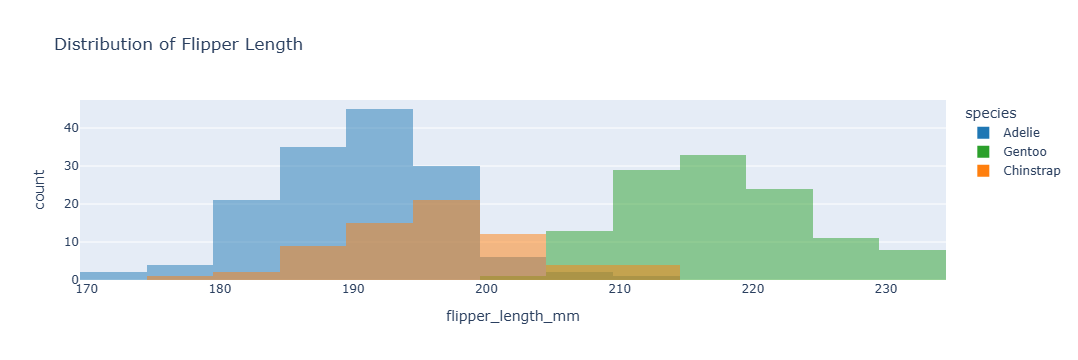

In [ ]:
#Alternative
fig_territory = px.bar(
    island_species,
    x="island",
    y="count",
    color="species",
    barmode="stack",
    color_discrete_map=species_colors,
    title="Adelie Appear on All Three Islands, While Gentoo and Chinstrap Appear on One Each",
    text="count"
)

fig_territory.update_layout(
    xaxis_title="Island",
    yaxis_title="Number of Penguins",
    plot_bgcolor="white",
    paper_bgcolor="white",
    yaxis=dict(showgrid=True, gridcolor="lightgray", zeroline=False),
    xaxis=dict(showgrid=False)
)

fig_territory.show()

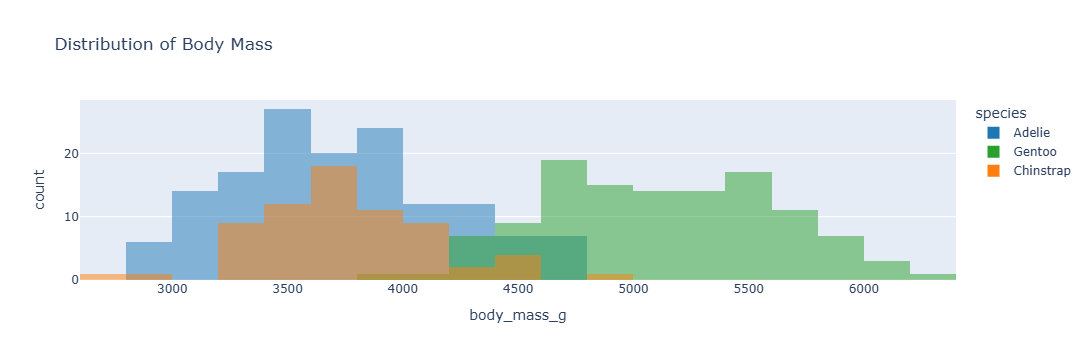

In [ ]:
fig = px.box(
    viz_df,
    x="species",
    y="body_mass_g",
    color="sex",
    color_discrete_map={
        "male": "#1f77b4",
        "female": "#ff7f0e"
    },
    title="Male Penguins Are Consistently Heavier Than Females Across All Species"
)

fig.update_layout(
    xaxis_title="Species",
    yaxis_title="Body Mass (g)",
    plot_bgcolor="white",
    paper_bgcolor="white",
    yaxis=dict(showgrid=True, gridcolor="lightgray", zeroline=False),
    xaxis=dict(showgrid=False)
)

fig.show()

In [1]:
fig = px.scatter(
    viz_df,
    x="flipper_length_mm",
    y="body_mass_g",
    color="species",
    color_discrete_map=species_colors,
    opacity=0.7,
    trendline="ols",
    title="Body Mass Increases with Flipper Length, and Species Form Distinct Clusters"
)

fig.update_layout(
    xaxis_title="Flipper Length (mm)",
    yaxis_title="Body Mass (g)",
    plot_bgcolor="white",
    paper_bgcolor="white",
    yaxis=dict(showgrid=True, gridcolor="lightgray", zeroline=False),
    xaxis=dict(showgrid=False)
)

fig.show()

NameError: name 'px' is not defined